# Editable GST Circuit Similarity Spiral

This notebook regenerates the `actual_gst_circuit_similarity_spiral.png` figure.

Edit the text/color variables in the first code cell, then run all cells. The plot uses saved GST/FPR CSV files from the parent `GST_POUNDERS` folder.


In [53]:
from pathlib import Path

# ===== Easy edit knobs =====
TITLE = "POUNDERS circuit selection for GST"
SUBTITLE = "nearby dots share circuit metadata: germ family, GST length, and fiducial-pair coordinates"
#FOOTER = "This is a metadata-similarity layout: the geometry is meaningful, not random."
OUTPUT_PDF_FILENAME = "actual_gst_circuit_similarity_spiral_edited.pdf"
OUTPUT_PNG_FILENAME = "actual_gst_circuit_similarity_spiral_edited.png"
EXPORT_DPI = 600  # high-resolution PNG export for printing

# ===== Dataset selection =====
# Pick WHICH run folder to plot.
#   DATA_ROOT  = None  -> use the ANL run that ships next to this notebook.
#              = a path (e.g. r"C:\Users\athar\Desktop\Tests") to browse another sweep.
#   MODEL_PACK / LENGTH_SET  -> subfolders under DATA_ROOT, e.g. "smq1Q_XYZI" / "1_2_4_8_16".
#     Leave both None when DATA_ROOT already points straight at the run folder.
# NOTE: the spiral needs the FPR pair-selection records
#   (target_selected_pair_records.csv + target_stage2_selected_fiducial_pairs.csv).
# Folders without them (e.g. the Desktop\Tests sweep) will stop with a clear
# message instead of drawing a fake spiral.
DATA_ROOT = None
MODEL_PACK = None
LENGTH_SET = "1_2_4_8_16"

# Choose one saved shot group from the sweep CSV. Set to None to use
# the largest shot count shared by the FPR and no-FPR runs.
# Examples: 500, 1000, 100000
SHOT_GROUP_TO_PLOT = 1000

# GST max-length rings to draw.
#   None       -> derive from LENGTH_SET folder name, else target_summary.json.
#   [1, 2]     -> show ONLY those rings (manual override).
LENGTHS = None

BACKGROUND = "#ffffff"
POOL_COLOR = "#b8c4d4"
TEXT_COLOR = "#101827"
MUTED_TEXT = "#53657d"
ACCENT_ORANGE = "#f28c00"
ACCENT_MINT = "#00a896"

POOL_DOT_SIZE = 6
SELECTED_DOT_SIZE = 16


In [54]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, FancyArrowPatch, Wedge

# The notebook can be launched either from GST_POUNDERS or from actual_data_visuals.
VIS_DIR = Path.cwd()
if VIS_DIR.name != "actual_data_visuals" and (VIS_DIR / "actual_data_visuals").exists():
    VIS_DIR = VIS_DIR / "actual_data_visuals"

# ----- Resolve WHICH run folder to read, from the dataset knobs -----
if DATA_ROOT is None:
    # Default: the ANL run that ships alongside this notebook.
    GST_DIR = VIS_DIR.parent
    FPR_RESULTS_DIR = GST_DIR / "near_minimal_fpr_stress_results"
else:
    run_dir = Path(DATA_ROOT)
    if MODEL_PACK:
        run_dir = run_dir / MODEL_PACK
    if LENGTH_SET:
        run_dir = run_dir / LENGTH_SET
    GST_DIR = run_dir
    # Pair-selection records may live in a subfolder or directly in the run folder.
    FPR_RESULTS_DIR = GST_DIR / "near_minimal_fpr_stress_results"
    if not FPR_RESULTS_DIR.exists():
        FPR_RESULTS_DIR = GST_DIR

SUMMARY_STEM = "pounders_fpr_shot_sweep_weighted_least_squares_cptplnd"
summary_path = GST_DIR / f"{SUMMARY_STEM}_summary.csv"
progress_path = GST_DIR / f"{SUMMARY_STEM}_progress.csv"


def _pick_path(*candidates):
    """Return the first candidate path that exists, else the first candidate."""
    for cand in candidates:
        if cand.exists():
            return cand
    return candidates[0]


def _shot_selection_stub(stem, shots):
    """Locate the per-shot FPR selection files that GST_model.ipynb now writes:
      {stem}_fpr_shots_{shots}_selected_pair_records.csv  (+ _stage2..., + _summary.json)
    If shots is None, use the largest available shot group in the run folder.
    """
    if shots is not None:
        return GST_DIR / f"{stem}_fpr_shots_{int(shots)}"
    matches = sorted(GST_DIR.glob(f"{stem}_fpr_shots_*_selected_pair_records.csv"))
    if matches:
        def _sh(p):
            m = re.search(r"_fpr_shots_(\d+)_", p.name)
            return int(m.group(1)) if m else -1
        best = max(matches, key=_sh)
        return GST_DIR / f"{stem}_fpr_shots_{_sh(best)}"
    return GST_DIR / f"{stem}_fpr_shots_NONE"  # non-existent -> falls back to target_* below


_stub = _shot_selection_stub(SUMMARY_STEM, SHOT_GROUP_TO_PLOT)
selected_pairs_path = _pick_path(
    Path(f"{_stub}_selected_pair_records.csv"),
    FPR_RESULTS_DIR / "target_selected_pair_records.csv",
)
stage2_path = _pick_path(
    Path(f"{_stub}_stage2_selected_fiducial_pairs.csv"),
    FPR_RESULTS_DIR / "target_stage2_selected_fiducial_pairs.csv",
)
target_summary_json_path = _pick_path(
    Path(f"{_stub}_summary.json"),
    FPR_RESULTS_DIR / "target_summary.json",
)

INPUT_FILES = {
    "selected pairs": selected_pairs_path,
    "stage 2 summary": stage2_path,
    "target summary json": target_summary_json_path,
    "shot-sweep summary": summary_path,
    "shot-sweep progress": progress_path,
}

print("Reading run folder:", GST_DIR)
for label, path in INPUT_FILES.items():
    print(f"  {label:20s}:", "found " if path.exists() else "MISSING", "|", path.name)

# The spiral is a fiducial-pair-selection picture, so it cannot be drawn without
# the per-pair selection records. Fail loudly and helpfully if they are absent.
_spiral_required = {"selected pairs": selected_pairs_path, "stage 2 summary": stage2_path}
_missing = [name for name, p in _spiral_required.items() if not p.exists()]
if _missing:
    raise FileNotFoundError(
        "This folder has no fiducial-pair selection records, so a spiral cannot be drawn.\n"
        f"  Folder : {GST_DIR}\n"
        f"  Missing: {', '.join(_missing)}\n"
        "The spiral needs the per-pair selection records (germ/prep/meas that FPR selected).\n"
        "Newer runs save them as\n"
        f"  {SUMMARY_STEM}_fpr_shots_<SHOTS>_selected_pair_records.csv  (+ _stage2..., + _summary.json)\n"
        "Re-run the sweep-shots cell in GST_model.ipynb with SHOT_SWEEP_SAVE_FPR_SELECTION=True to\n"
        "generate them, then point DATA_ROOT/MODEL_PACK/LENGTH_SET at that folder."
    )


Reading run folder: /workspace/IBCDFO/GST_POUNDERS
  selected pairs      : found  | target_selected_pair_records.csv
  stage 2 summary     : found  | target_stage2_selected_fiducial_pairs.csv
  target summary json : found  | target_summary.json
  shot-sweep summary  : MISSING | pounders_fpr_shot_sweep_weighted_least_squares_cptplnd_summary.csv
  shot-sweep progress : MISSING | pounders_fpr_shot_sweep_weighted_least_squares_cptplnd_progress.csv


In [55]:
# Load saved experiment data and infer the plotting metadata automatically.
import json


def require_file(path, label):
    if not path.exists():
        raise FileNotFoundError(f"Missing {label}: {path}")
    return path


def first_existing_column(df, candidates, *, required=True, label="column"):
    for column in candidates:
        if column in df.columns:
            return column
    if required:
        raise KeyError(f"Could not find {label}. Tried: {candidates}. Available: {list(df.columns)}")
    return None


def infer_count(dataframes, candidate_columns):
    max_values = []
    for df in dataframes:
        for column in candidate_columns:
            if column in df.columns:
                values = pd.to_numeric(df[column], errors="coerce").dropna()
                if len(values):
                    max_values.append(int(values.max()))
    return max(max_values) + 1 if max_values else None


def clean_length_list(raw_values):
    """Coerce an arbitrary iterable/string of lengths into a sorted int array.

    Accepts commas, semicolons, underscores (folder names like '1_2_4_8_16'),
    and bracketed lists.
    """
    values = set()
    for raw in raw_values:
        cleaned = str(raw)
        for ch in "[]()_;":
            cleaned = cleaned.replace(ch, ",")
        for piece in cleaned.split(","):
            piece = piece.strip()
            if not piece:
                continue
            try:
                value = int(float(piece))
            except ValueError:
                continue
            if value > 0:
                values.add(value)
    return np.array(sorted(values), dtype=int)


def lengths_from_summary_json(path):
    """Read the real GST max_lengths from the run's summary JSON, if present."""
    if not path.exists():
        return None
    try:
        with open(path) as fh:
            data = json.load(fh)
    except (json.JSONDecodeError, OSError):
        return None
    for key in ("max_lengths", "max_length", "gst_max_lengths", "lengths", "L"):
        if key in data and data[key] is not None:
            values = data[key] if isinstance(data[key], (list, tuple)) else [data[key]]
            lengths = clean_length_list(values)
            if len(lengths):
                return lengths
    return None


def infer_lengths_from_tables(*dataframes, fallback=(1, 2, 4, 8, 16, 32)):
    """Infer GST max-length rings when a saved table contains length metadata.

    The selected-pair CSVs usually contain germ/fiducial indices but not max
    lengths, so this function falls back to the standard powers-of-two GST list.
    """
    candidate_columns = [
        "L",
        "max_length",
        "max_lengths",
        "metadata_max_lengths",
        "gst_length",
        "length",
        "max_L",
    ]
    values = set()
    for df in dataframes:
        if df is None or df.empty:
            continue
        for column in candidate_columns:
            if column not in df.columns:
                continue
            found = clean_length_list(df[column].dropna())
            values.update(int(v) for v in found)
    if values:
        return np.array(sorted(values), dtype=int), "inferred from saved tables"
    return np.array(list(fallback), dtype=int), "fallback powers of two"


def resolve_lengths(manual_lengths, length_set_name, summary_json_path, *dataframes):
    """Pick the GST length rings, in priority order:

    1. Manual LENGTHS knob (if set).
    2. The LENGTH_SET folder name (e.g. '1_2_4_8_16').
    3. Real max_lengths from the run's summary JSON.
    4. A length column in one of the saved CSV tables.
    5. Hardcoded powers-of-two fallback (last resort).
    """
    if manual_lengths is not None:
        lengths = clean_length_list(manual_lengths)
        if not len(lengths):
            raise ValueError(f"LENGTHS={manual_lengths!r} did not contain any positive integers.")
        return lengths, "manual LENGTHS knob"

    if length_set_name:
        lengths = clean_length_list([length_set_name])
        if len(lengths):
            return lengths, f"parsed from LENGTH_SET folder name '{length_set_name}'"

    json_lengths = lengths_from_summary_json(summary_json_path)
    if json_lengths is not None:
        return json_lengths, f"read from {summary_json_path.name}"

    return infer_lengths_from_tables(*dataframes)


def load_optional_csv(path):
    return pd.read_csv(path) if path.exists() else pd.DataFrame()


def pick_matching_summary_rows(summary, requested_shots=None):
    """Pick one FPR/no-FPR pair from a summary table.

    If requested_shots is set, use exactly that shot group. If it is None,
    use the largest shot count shared by the FPR and no-FPR runs.
    """
    if summary.empty or "use_fpr_reduction" not in summary.columns:
        return None, None, None

    fpr_rows = summary[summary["use_fpr_reduction"].astype(str).str.lower().eq("true")].copy()
    no_fpr_rows = summary[summary["use_fpr_reduction"].astype(str).str.lower().eq("false")].copy()
    if fpr_rows.empty or no_fpr_rows.empty:
        return None, None, None

    if "shots_per_circuit" in summary.columns:
        fpr_shots = set(pd.to_numeric(fpr_rows["shots_per_circuit"], errors="coerce").dropna())
        no_fpr_shots = set(pd.to_numeric(no_fpr_rows["shots_per_circuit"], errors="coerce").dropna())
        common_shots = sorted(fpr_shots.intersection(no_fpr_shots))

        if requested_shots is not None:
            requested_shots = float(requested_shots)
            if requested_shots not in common_shots:
                available = [int(value) if float(value).is_integer() else value for value in common_shots]
                raise ValueError(
                    f"SHOT_GROUP_TO_PLOT={requested_shots:g} is not available for both FPR and no-FPR. "
                    f"Available common shot groups: {available}"
                )
            chosen_shots = requested_shots
        elif common_shots:
            chosen_shots = common_shots[-1]
        else:
            chosen_shots = None

        if chosen_shots is not None:
            fpr_shot_values = pd.to_numeric(fpr_rows["shots_per_circuit"], errors="coerce")
            no_fpr_shot_values = pd.to_numeric(no_fpr_rows["shots_per_circuit"], errors="coerce")
            fpr_row = fpr_rows[fpr_shot_values.eq(chosen_shots)].iloc[-1]
            no_fpr_row = no_fpr_rows[no_fpr_shot_values.eq(chosen_shots)].iloc[-1]
            return fpr_row, no_fpr_row, chosen_shots

    return fpr_rows.iloc[-1], no_fpr_rows.iloc[-1], None


selected_pairs = pd.read_csv(require_file(selected_pairs_path, "selected pair records"))
stage2 = pd.read_csv(require_file(stage2_path, "stage-2 selected fiducial pairs"))
summary = load_optional_csv(summary_path)
progress = load_optional_csv(progress_path)

GERM_COL = first_existing_column(selected_pairs, ["germ_index", "germ"], label="germ index")
PREP_COL = first_existing_column(selected_pairs, ["prep_fiducial_index", "prep", "prep_index"], label="prep fiducial index")
MEAS_COL = first_existing_column(selected_pairs, ["meas_fiducial_index", "meas", "meas_index"], label="meas fiducial index")
STAGE2_GERM_COL = first_existing_column(stage2, ["germ_index", "germ"], label="stage-2 germ index")

num_germs = infer_count([selected_pairs, stage2], ["germ_index", "germ"])
num_prep = infer_count([selected_pairs, stage2], ["prep_fiducial_index", "prep", "prep_index"])
num_meas = infer_count([selected_pairs, stage2], ["meas_fiducial_index", "meas", "meas_index"])
lengths, lengths_source = resolve_lengths(LENGTHS, LENGTH_SET, target_summary_json_path, selected_pairs, stage2, summary, progress)
num_lengths = len(lengths)

missing = [
    name
    for name, value in {"num_germs": num_germs, "num_prep": num_prep, "num_meas": num_meas}.items()
    if value is None
]
if missing:
    raise ValueError(f"Could not infer required metadata values: {missing}")

fpr_summary, no_fpr_summary, chosen_summary_shots = pick_matching_summary_rows(summary, SHOT_GROUP_TO_PLOT)

if fpr_summary is not None and no_fpr_summary is not None:
    full_circuits = int(no_fpr_summary.get("final_union_circuits", no_fpr_summary.get("num_circuits", np.nan)))
    final_selected = int(fpr_summary.get("final_union_circuits", fpr_summary.get("num_circuits", np.nan)))
    shots_fpr = float(fpr_summary.get("final_revealed_shots", np.nan))
    shots_full = float(no_fpr_summary.get("final_revealed_shots", np.nan))
else:
    full_circuits = int(num_germs * num_prep * num_meas * num_lengths)
    final_selected = min(int(len(selected_pairs) * num_lengths), full_circuits)
    shots_fpr = np.nan
    shots_full = np.nan

print("Inferred num_germs:", num_germs)
print("Inferred num_prep_fiducials:", num_prep)
print("Inferred num_meas_fiducials:", num_meas)
print("Inferred GST lengths:", lengths.tolist(), f"({lengths_source})")
if chosen_summary_shots is not None:
    print("Using summary rows with shots_per_circuit:", int(chosen_summary_shots))
print(f"FPR selected/revealed circuits: {final_selected:,} / {full_circuits:,}")
if np.isfinite(shots_fpr) and np.isfinite(shots_full):
    print(f"Revealed shots: FPR {shots_fpr/1e6:.2f}M vs no FPR {shots_full/1e6:.2f}M")

selected_pairs.head()


Inferred num_germs: 15
Inferred num_prep_fiducials: 16
Inferred num_meas_fiducials: 11
Inferred GST lengths: [1, 2, 4, 8, 16] (parsed from LENGTH_SET folder name '1_2_4_8_16')
FPR selected/revealed circuits: 4,055 / 13,200


,germ_index,prep_fiducial_index,meas_fiducial_index
0,0,15,10
1,0,14,7
2,0,15,4
3,0,3,3
4,0,14,10


In [56]:
# Build a GST metadata pool and mark FPR-selected regions.
# Geometry meaning:
#   angle sector = germ index
#   radius ring = GST max length L
#   local offset = prep/meas fiducial coordinates
#
# All core counts are inferred in the previous cell from the saved CSVs.

selected_pair_set = set(
    (int(getattr(r, GERM_COL)), int(getattr(r, PREP_COL)), int(getattr(r, MEAS_COL)))
    for r in selected_pairs.itertuples(index=False)
)

all_meta = []
for g in range(num_germs):
    for l_idx, L in enumerate(lengths):
        for p in range(num_prep):
            for m in range(num_meas):
                all_meta.append((g, l_idx, int(L), p, m))
all_meta = pd.DataFrame(all_meta, columns=["germ", "length_index", "L", "prep", "meas"])

# Thin metadata grid to the actual full-circuit count from the selected run.
# This keeps the visual count aligned with the saved sweep summary while still
# arranging nearby dots by GST metadata.
score_hash = (
    0.61803398875 * (all_meta["germ"] + 1)
    + 0.41421356237 * (all_meta["length_index"] + 1)
    + 0.73205080757 * (all_meta["prep"] + 1)
    + 0.23606797750 * (all_meta["meas"] + 1)
) % 1.0
all_meta = all_meta.assign(hash_score=score_hash)
if full_circuits < len(all_meta):
    all_meta = all_meta.sort_values("hash_score").head(full_circuits).copy()
all_meta = all_meta.reset_index(drop=True)

if "selected_directions_r_g" in stage2.columns:
    germ_strength = stage2.set_index(STAGE2_GERM_COL)["selected_directions_r_g"].astype(float)
else:
    germ_strength = selected_pairs.groupby(GERM_COL).size().astype(float)
germ_strength = germ_strength / max(float(germ_strength.max()), 1.0)

all_meta["pair_selected"] = [
    (int(g), int(p), int(m)) in selected_pair_set
    for g, p, m in zip(all_meta["germ"], all_meta["prep"], all_meta["meas"])
]
all_meta["germ_strength"] = all_meta["germ"].map(germ_strength).fillna(0.0)
all_meta["fpr_score"] = (
    10.0 * all_meta["pair_selected"].astype(float)
    + 1.5 * all_meta["germ_strength"]
    + 0.20 * all_meta["length_index"]
    + 0.01 * ((all_meta["prep"] * max(num_meas, 1) + all_meta["meas"]) % 17)
)
selected_indices = all_meta.sort_values("fpr_score", ascending=False).head(final_selected).index
all_meta["selected"] = False
all_meta.loc[selected_indices, "selected"] = True

sector = 2*np.pi / num_germs
pair_denominator = max(num_prep*num_meas - 1, 1)
pair_order = (all_meta["prep"].to_numpy() * num_meas + all_meta["meas"].to_numpy()) / pair_denominator
g = all_meta["germ"].to_numpy()
l_idx = all_meta["length_index"].to_numpy()
prep = all_meta["prep"].to_numpy()
meas = all_meta["meas"].to_numpy()

r_base = 1.02 - 0.145 * l_idx
r = r_base + 0.035 * np.sin(2*np.pi*pair_order) + 0.008*np.cos(prep)
local = (pair_order - 0.5) * sector * 0.72
theta = g * sector + local + 0.19*l_idx + 0.028*np.sin(meas)
all_meta["x"] = r*np.cos(theta)
all_meta["y"] = r*np.sin(theta)

print("Generated metadata dots:", len(all_meta))
print("Marked selected dots:", int(all_meta["selected"].sum()))
print("Selected pair records read:", len(selected_pair_set))
all_meta.head()


Generated metadata dots: 13200
Marked selected dots: 4055
Selected pair records read: 811


,germ,length_index,L,prep,meas,hash_score,pair_selected,germ_strength,fpr_score,selected,x,y
0,0,0,1,0,0,0.000366,True,1.0,11.50,True,1.016334,-0.154432
1,0,0,1,0,1,0.236434,True,1.0,11.51,True,1.021160,-0.128845
2,0,0,1,0,2,0.472502,False,1.0,1.52,False,1.022865,-0.125298
3,0,0,1,0,3,0.708570,False,1.0,1.53,False,1.021425,-0.145686
4,0,0,1,0,4,0.944638,True,1.0,11.54,True,1.018963,-0.169769


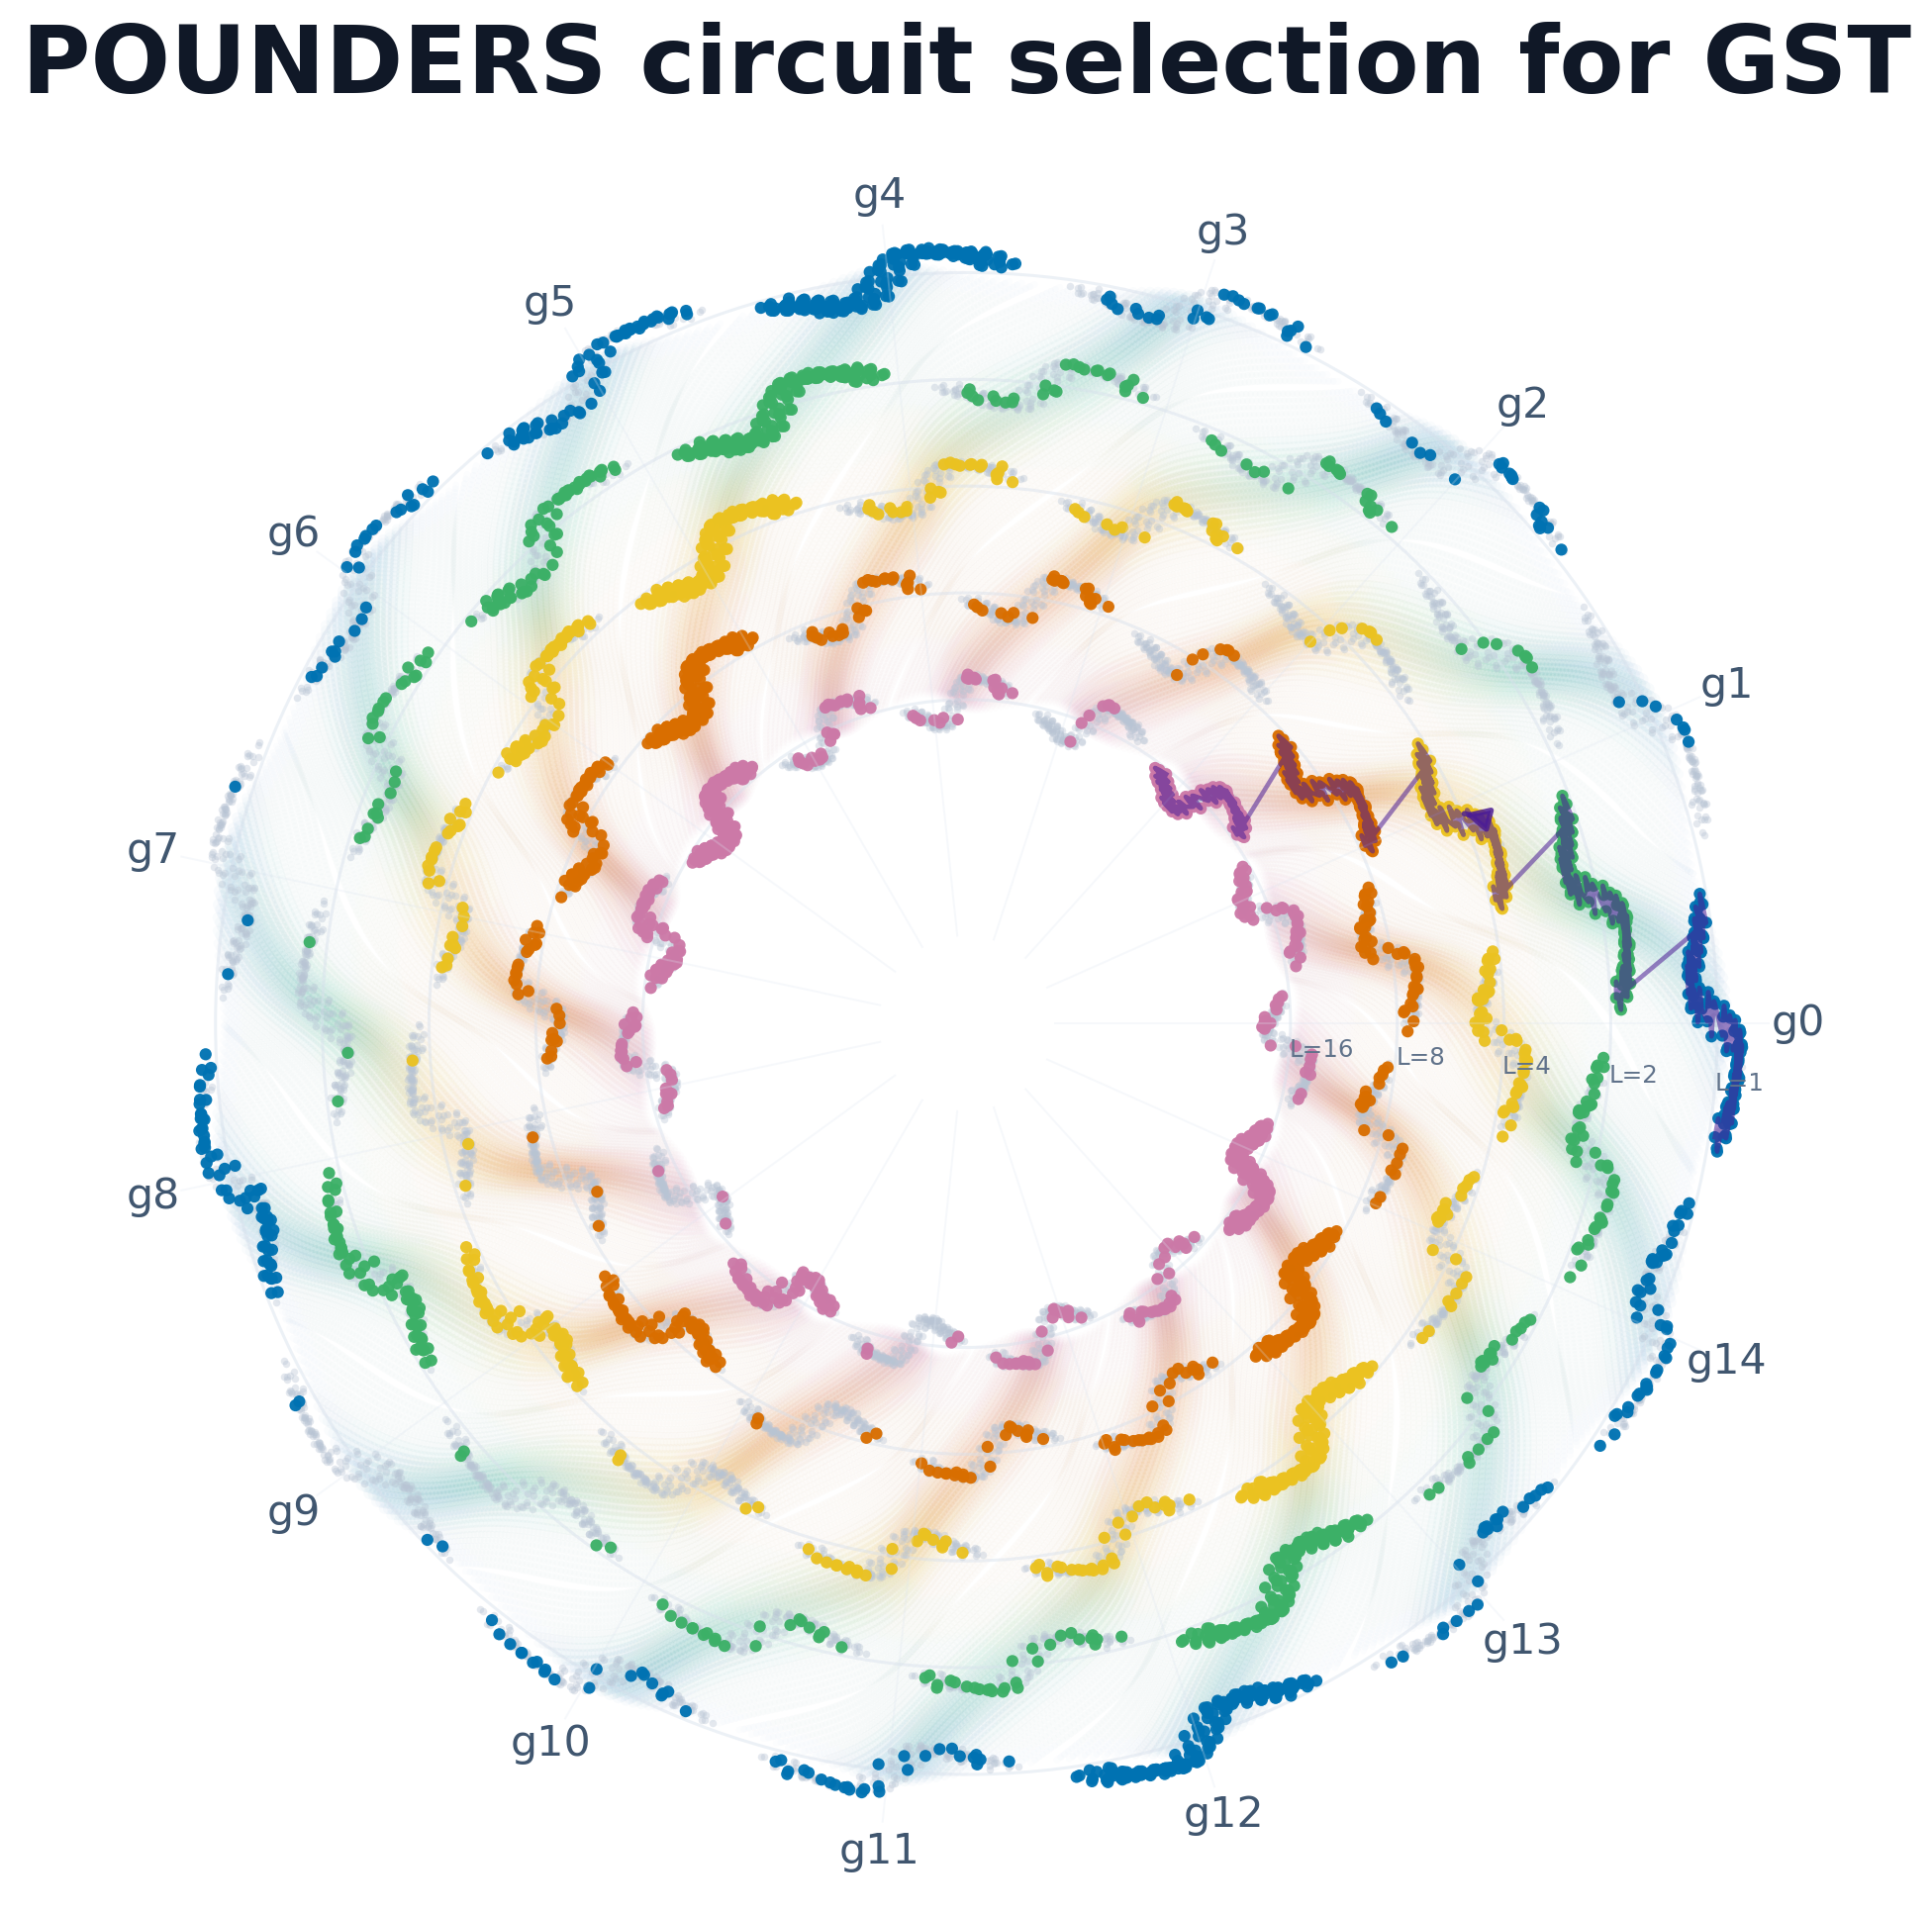

Saved: /workspace/IBCDFO/GST_POUNDERS/actual_data_visuals/actual_gst_circuit_similarity_spiral_edited.pdf


In [58]:
# Generate and save the figure.
# Force the white print theme here too, so rerunning only this cell is enough.
BACKGROUND = "#ffffff"
POOL_COLOR = "#b8c4d4"
TEXT_COLOR = "#101827"
MUTED_TEXT = "#53657d"
ACCENT_ORANGE = "#f28c00"
ACCENT_MINT = "#00a896"

fig = plt.figure(figsize=(18, 9.5), dpi=220)
fig.patch.set_facecolor(BACKGROUND)
ax = fig.add_axes([0.10, 0.07, 0.80, 0.84])
ax.set_facecolor(BACKGROUND)
ax.set_aspect("equal")
ax.axis("off")

ax.set_xlim(-1.24, 1.24)
ax.set_ylim(-1.18, 1.18)

# Length rings.
for i, L in enumerate(lengths):
    rr = 1.02 - 0.145*i
    ax.add_patch(Circle((0, 0), rr, edgecolor="#d7e0ec", facecolor="none", lw=1.0, alpha=0.45))
    ax.text(rr*np.cos(-0.08), rr*np.sin(-0.08), f"L={L}", color="#60728a", fontsize=8, ha="left", va="center")

# Germ sector guide lines.
for gg in range(num_germs):
    th = gg*sector
    ax.plot([0.12*np.cos(th), 1.09*np.cos(th)], [0.12*np.sin(th), 1.09*np.sin(th)],
            color="#dce5f1", lw=0.65, alpha=0.25)
    ax.text(1.13*np.cos(th), 1.13*np.sin(th), f"g{gg}", color="#40566f", fontsize=14,
            ha="center", va="center")

# Very faint germ-spiral memory trails.
# These follow the same germ/length geometry as the data points:
# angle sector = germ, radius = GST length, and the length-dependent
# angular drift makes each background trail curve along the spiral.
from matplotlib.collections import LineCollection

TRAIL_PALETTE = np.array([
    [0x00, 0x72, 0xB2],  # outer L=1 blue
    [0x00, 0x9E, 0x73],  # teal
    [0xE6, 0x9F, 0x00],  # gold
    [0xD5, 0x5E, 0x00],  # warm orange
    [0xCC, 0x79, 0xA7],  # inner L=16 soft magenta
], dtype=float) / 255.0

def trail_color(u, alpha):
    u = float(np.clip(u, 0.0, 1.0))
    color_position = u * (len(TRAIL_PALETTE) - 1)
    lo = int(np.floor(color_position))
    hi = min(lo + 1, len(TRAIL_PALETTE) - 1)
    frac = color_position - lo
    rgb = (1.0 - frac) * TRAIL_PALETTE[lo] + frac * TRAIL_PALETTE[hi]
    return (float(rgb[0]), float(rgb[1]), float(rgb[2]), float(alpha))

trail_steps = 170
trail_t = np.linspace(0.0, num_lengths - 1.0, trail_steps)
trail_u = trail_t / max(num_lengths - 1.0, 1.0)
trail_offsets = np.linspace(-0.48, 0.48, 30)

for gg in range(num_germs):
    for offset in trail_offsets:
        # Same center formula as the point cloud, with a tiny deterministic
        # wiggle so the background follows the visible circuit-selection path.
        theta_curve = (
            gg * sector
            + offset * sector
            + 0.19 * trail_t
            + 0.018 * np.sin(2*np.pi*(trail_u*2.2 + 0.13*gg + offset))
        )
        r_curve = (
            1.02
            - 0.145 * trail_t
            + 0.012 * np.cos(2*np.pi*(trail_u*1.7 + offset))
        )
        xy = np.column_stack([r_curve * np.cos(theta_curve), r_curve * np.sin(theta_curve)])
        segments = np.stack([xy[:-1], xy[1:]], axis=1)

        center_weight = 1.0 - min(abs(offset) / 0.34, 1.0)
        line_width = 2.2 + 2.3 * center_weight
        colors_for_segments = [
            trail_color(0.5*(trail_u[j] + trail_u[j + 1]), 0.010 + 0.02 * center_weight)
            for j in range(trail_steps - 1)
        ]
        ax.add_collection(LineCollection(
            segments,
            colors=colors_for_segments,
            linewidths=line_width,
            capstyle="round",
            joinstyle="round",
            zorder=0,
        ))

unselected = all_meta[~all_meta["selected"]]
selected = all_meta[all_meta["selected"]]
ax.scatter(unselected["x"], unselected["y"], s=POOL_DOT_SIZE, c=POOL_COLOR, alpha=0.38, linewidths=0)

# Selected-dot colors are generated from a continuous palette so the
# notebook works for any inferred number of GST length rings.
SELECTED_PALETTE = np.array([
    [0x00, 0x72, 0xB2],  # blue
    [0x00, 0x9E, 0x73],  # teal
    [0xF0, 0xE4, 0x42],  # yellow
    [0xE6, 0x9F, 0x00],  # orange
    [0xD5, 0x5E, 0x00],  # vermillion
    [0xCC, 0x79, 0xA7],  # purple
], dtype=float) / 255.0

selected_length_index = selected["length_index"].to_numpy(dtype=float)
selected_position = selected_length_index / max(num_lengths - 1, 1)
palette_position = selected_position * (len(SELECTED_PALETTE) - 1)
lo = np.floor(palette_position).astype(int)
hi = np.clip(lo + 1, 0, len(SELECTED_PALETTE) - 1)
frac = (palette_position - lo)[:, None]
sel_colors = (1.0 - frac) * SELECTED_PALETTE[lo] + frac * SELECTED_PALETTE[hi]
ax.scatter(selected["x"], selected["y"], s=SELECTED_DOT_SIZE, c=sel_colors, alpha=0.96, linewidths=0)

# Optional illustrative path through one germ sector.
path = selected[selected["germ"].eq(0)].sort_values(["length_index", "prep", "meas"])
if len(path) > 3:
    ax.plot(path["x"], path["y"], color="#4C1D95", lw=1.5, alpha=0.55)
    mid = len(path)//2
    ax.add_patch(FancyArrowPatch(
        (path["x"].iloc[mid-2], path["y"].iloc[mid-2]),
        (path["x"].iloc[mid+2], path["y"].iloc[mid+2]),
        arrowstyle="-|>", mutation_scale=16, lw=1.8, color="#4C1D95", alpha=0.85
    ))

# # Center label.
# ax.add_patch(Circle((0, 0), 0.20, facecolor=BACKGROUND, edgecolor="#cad5e4", lw=1.2, alpha=0.94, zorder=6))
# ax.text(0, 0.055, f"{final_selected:}", color=TEXT_COLOR, fontsize=22, ha="center", va="center", weight="bold", zorder=7)
# ax.text(0, -0.015, f"/ {full_circuits:}", color=TEXT_COLOR, fontsize=16, ha="center", va="center", weight="bold", zorder=7)
# ax.text(0, -0.105, "circuits selected", color="#5f6f85", fontsize=10, ha="center", zorder=7)

fig.text(0.5, 0.94, TITLE, color=TEXT_COLOR, fontsize=31, weight="bold", ha="center")
# fig.text(0.055, 0.895, SUBTITLE, color=MUTED_TEXT, fontsize=13)

# Right explanation panel removed so the spiral stays centered.
# axr = fig.add_axes([0.67, 0.14, 0.30, 0.74])
# axr.set_facecolor(BACKGROUND)
# axr.axis("off")
# axr.text(0.00, 0.97, "What closeness means", color=TEXT_COLOR, fontsize=21, weight="bold", transform=axr.transAxes)
# items = [
#     ("angle spiraling inwards", "same sector = same germ family", None),
#     ("radius", "same ring = same GST max length L", None),
#     ("color", "orange/mint = FPR-selected region", (ACCENT_ORANGE, ACCENT_MINT)),
# ]
# for i, (head, body, item_colors) in enumerate(items):
#     yy = 0.83 - i*0.16
#     if item_colors is None:
#         text_x = 0.01
#     else:
#         axr.add_patch(Circle((0.020, yy+0.012), 0.020, transform=axr.transAxes, color=item_colors[0]))
#         axr.add_patch(Circle((0.050, yy+0.012), 0.020, transform=axr.transAxes, color=item_colors[1]))
#         text_x = 0.09
#     axr.text(text_x, yy+0.035, head, color=TEXT_COLOR, fontsize=14, weight="bold", transform=axr.transAxes)
#     axr.text(text_x, yy-0.005, body, color="#5f6f85", fontsize=11, transform=axr.transAxes)

# axr.text(0.00, 0.22, "Approximate 35% shot reduction", color=TEXT_COLOR, fontsize=18, weight="bold", transform=axr.transAxes)
# axr.text(0.00, 0.16, "Follow one arm inward: same germ, increasing GST length,\nwith nearby fiducial-pair variants clustered together.",
#          color=MUTED_TEXT, fontsize=10.7, transform=axr.transAxes)
# axr.text(0.00, 0.055, f"Actual sweep: {shots_fpr/1e6:.2f}M vs {shots_full/1e6:.2f}M revealed shots",
#          color=ACCENT_MINT, fontsize=13.5, weight="bold", transform=axr.transAxes)

# fig.text(0.50, 0.035, FOOTER, color=ACCENT_MINT, fontsize=16, weight="bold", ha="center")

# fig.text(0.27, 0.080, "by Atharva Vidwans", color="#000000", fontsize=18, ha="left", va="bottom")
pdf_outpath = VIS_DIR / OUTPUT_PDF_FILENAME
png_outpath = VIS_DIR / OUTPUT_PNG_FILENAME
save_kwargs = {
    "facecolor": "#ffffff",
    "edgecolor": "none",
    "bbox_inches": "tight",
    "pad_inches": 0.04,
}
fig.savefig(pdf_outpath, **save_kwargs)
fig.savefig(png_outpath, dpi=EXPORT_DPI, **save_kwargs)
plt.show()
print("Saved vector PDF:", pdf_outpath)
print(f"Saved {EXPORT_DPI}-DPI PNG:", png_outpath)
